In [1]:
import fasttext.util
fasttext.util.download_model('en', if_exists='ignore')
fasttext.util.download_model('hi', if_exists='ignore')
fasttext.util.download_model('sw', if_exists='ignore')
fasttext.util.download_model('zh', if_exists='ignore')

'cc.zh.300.bin'

In [2]:
# san jose
en = fasttext.load_model('cc.en.300.bin')
# new delhi
hi = fasttext.load_model('cc.hi.300.bin')
# kisumu
sw = fasttext.load_model('cc.sw.300.bin')
# beijing
zh = fasttext.load_model('cc.zh.300.bin')

In [62]:
sw_words = sw.get_words()
en_words = en.get_words()
hi_words = hi.get_words()
zh_words = zh.get_words()

In [63]:
from pathlib import Path
import pandas as pd
embedding_dir = Path("../../data/embeddings/")
stores = pd.read_parquet(Path("../../data/emb_df.parquet"))

In [5]:
stores.head()

,location,age,participant_id,drawing_category,embedding,recognized,target_similarity
0,Beijing,9,THU9M2,cat,"[-0.07537841796875, -0.386962890625, 0.1663818...",True,0.299561
1,Beijing,5,THU5M7,cat,"[0.29931640625, 0.1563720703125, 0.01675415039...",False,0.256104
2,Beijing,4,THU4F8,car,"[0.1192626953125, 0.11724853515625, -0.0178222...",True,0.281250
3,Beijing,8,THU8F12,bird,"[0.3046875, -0.052520751953125, 0.45361328125,...",True,0.305420
4,Beijing,5,THU6M1,cup,"[0.1611328125, -0.08026123046875, 0.0364990234...",False,0.281982


translations were first grabbed form the NorthEuraLex dataset similar to Thompson et al., 2020. missing translations were then manually added translations, used Wikipedia page names and the drawing labels from the actual experiments as additional labels. however, definitely some questions about how robust these values are based on language coverage/concept coverage in datasets.


In [6]:
cats = list(stores['drawing_category'].unique())
en_hi = pd.read_csv('../../data/nel-translations/en-hi.csv')
en_zh = pd.read_csv('../../data/nel-translations/en-zh.csv')

rows = []
for cat in cats:
    hi_match = en_hi[en_hi['en'] == cat]
    zh_match = en_zh[en_zh['en'] == cat]

    hi_val = hi_match['hi'].values[0] if not hi_match.empty else None
    zh_val = zh_match['zh'].values[0] if not zh_match.empty else None

    rows.append({'en': cat, 'hi': hi_val, 'zh': zh_val})

translations = pd.DataFrame(rows)
translations.to_csv('../../data/nel-translations/en-hi-zh.csv', index=False)

comparing rdms for each language.

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

# load translations / word list
translations = pd.read_csv('../../data/nel-translations/en-hi-zh-sw.csv')

# helper to get vectors for a model using its own language column
def vectors_for_model(model, words):
    for word in words:
        if word not in model.get_words():
            print(f"Warning: '{word}' not in model vocab")
    vecs = [model.get_sentence_vector(str(w)) for w in words]
    return np.vstack(vecs)

# compute embeddings for each language model using language-appropriate words
en_vecs = vectors_for_model(en, translations['en'])
hi_vecs = vectors_for_model(hi, translations['hi'])
zh_vecs = vectors_for_model(zh, translations['zh'])
sw_vecs = vectors_for_model(sw, translations['sw'])

# compute RDM (1 - cosine_similarity) for each
def rdm_from_vecs(vecs):
    sim = cosine_similarity(vecs)
    return 1.0 - sim

rdm_en = rdm_from_vecs(en_vecs)
rdm_hi = rdm_from_vecs(hi_vecs)
rdm_zh = rdm_from_vecs(zh_vecs)
rdm_sw = rdm_from_vecs(sw_vecs)

# extract lower-triangle (excluding diagonal) as vector
def lower_tri_vec(mat):
    n = mat.shape[0]
    i, j = np.tril_indices(n, -1)
    return mat[i, j]

pairs = {'en': rdm_en, 'hi': rdm_hi, 'zh': rdm_zh, 'sw': rdm_sw}
langs = list(pairs.keys())
corr_matrix = pd.DataFrame(index=langs, columns=langs, dtype=float)

for i, la in enumerate(langs):
    for j, lb in enumerate(langs):
        if i <= j:
            v1 = lower_tri_vec(pairs[la])
            v2 = lower_tri_vec(pairs[lb])
            rho, p = spearmanr(v1, v2)
            corr_matrix.loc[la, lb] = rho
            corr_matrix.loc[lb, la] = rho

corr_matrix


,en,hi,zh,sw
en,1.000000,0.356184,0.350381,0.483519
hi,0.356184,1.000000,0.328671,0.311471
zh,0.350381,0.328671,1.000000,0.220332
sw,0.483519,0.311471,0.220332,1.000000


this plot is just messing around to make sure our use of sentence vectors here makes sense.

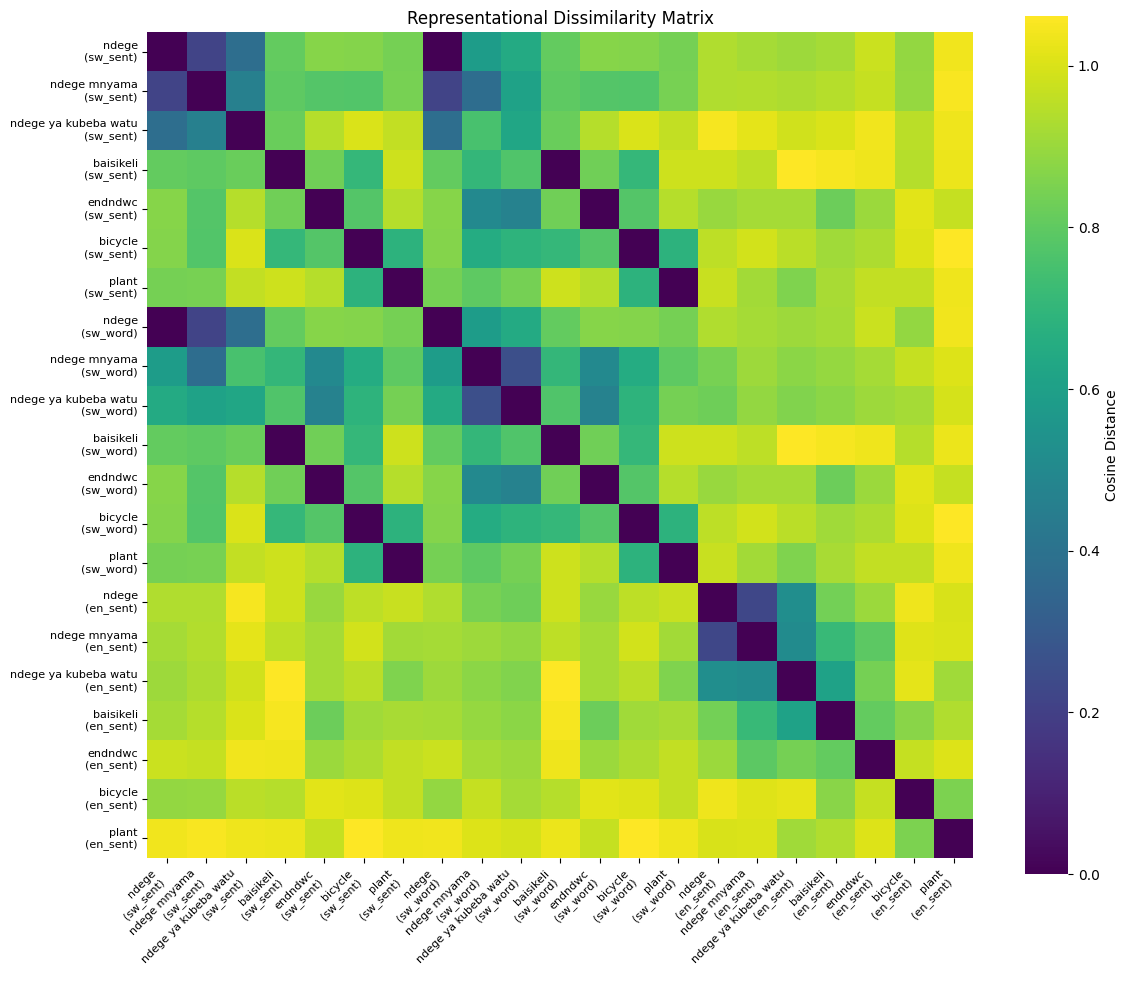

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
methods = ['sw_sent', 'sw_word', 'en_sent']
labels = ['ndege', 'ndege mnyama', 'ndege ya kubeba watu', 'baisikeli', 'endndwc', 'bicycle', 'plant']
expanded_labels = [f"{label}\n({method})" for method in methods for label in labels]

vecs = np.stack(
    [sw.get_sentence_vector(label) for label in labels] +
    [sw.get_word_vector(label) for label in labels] +
    [en.get_sentence_vector(label) for label in labels]
)

# RDM = 1 - cosine similarity
rdm = 1 - cosine_similarity(vecs)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(rdm, xticklabels=expanded_labels, yticklabels=expanded_labels,
            cmap='viridis', ax=ax, square=True,
            cbar_kws={'label': 'Cosine Distance'})
ax.set_title('Representational Dissimilarity Matrix')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

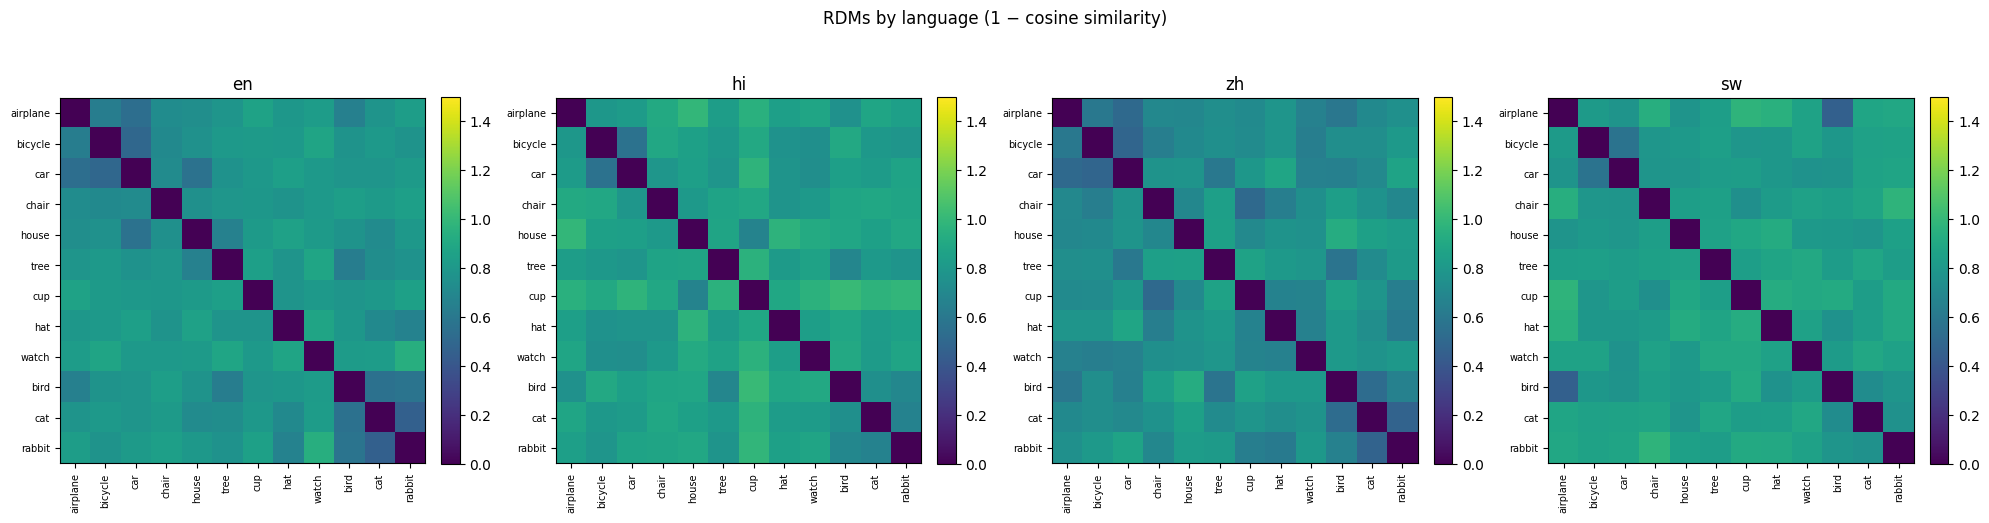

In [13]:
import matplotlib.pyplot as plt

CATEGORIES_GROUPED = [
    "airplane", "bicycle", "car", "chair", "house", "tree",
    "cup", "hat", "watch",
    "bird", "cat", "rabbit",
]

# reorder RDM rows/cols to match CATEGORIES_GROUPED
all_cats = translations['en'].tolist()
idx = [all_cats.index(c) for c in CATEGORIES_GROUPED]

rdms = {'en': rdm_en, 'hi': rdm_hi, 'zh': rdm_zh, 'sw': rdm_sw}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (lang, rdm) in zip(axes, rdms.items()):
    rdm_ordered = rdm[np.ix_(idx, idx)]
    im = ax.imshow(rdm_ordered, vmin=0, vmax=1.5, cmap='viridis')
    ax.set_title(lang)
    ax.set_xticks(range(len(CATEGORIES_GROUPED)))
    ax.set_yticks(range(len(CATEGORIES_GROUPED)))
    ax.set_xticklabels(CATEGORIES_GROUPED, rotation=90, fontsize=7)
    ax.set_yticklabels(CATEGORIES_GROUPED, fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('RDMs by language (1 − cosine similarity)', y=1.02)
plt.tight_layout()
plt.show()


In [65]:
emb_matrix = np.vstack(stores['embedding'].values)  # (N, d)
mu  = emb_matrix.mean(axis=0)
std = emb_matrix.std(axis=0)
std[std == 0] = 1
stores['embedding_zscored'] = list((emb_matrix - mu) / std)

Computed 24 drawing RDMs ([raw embeddings])


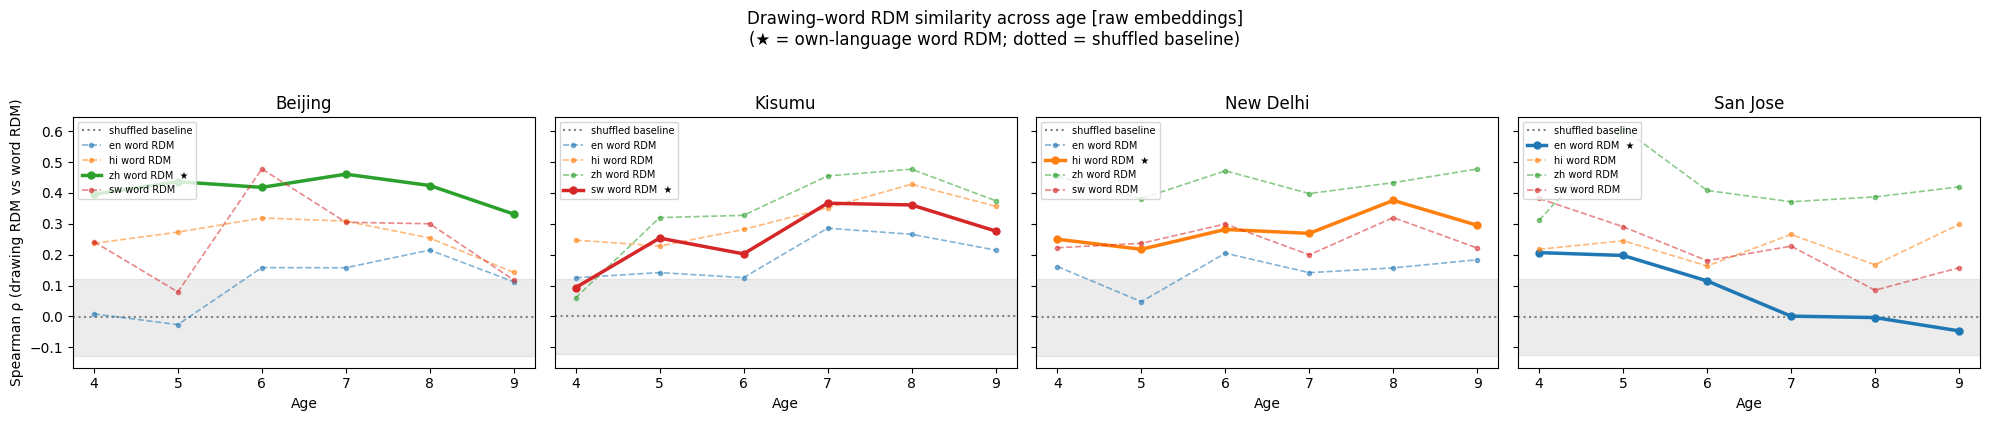

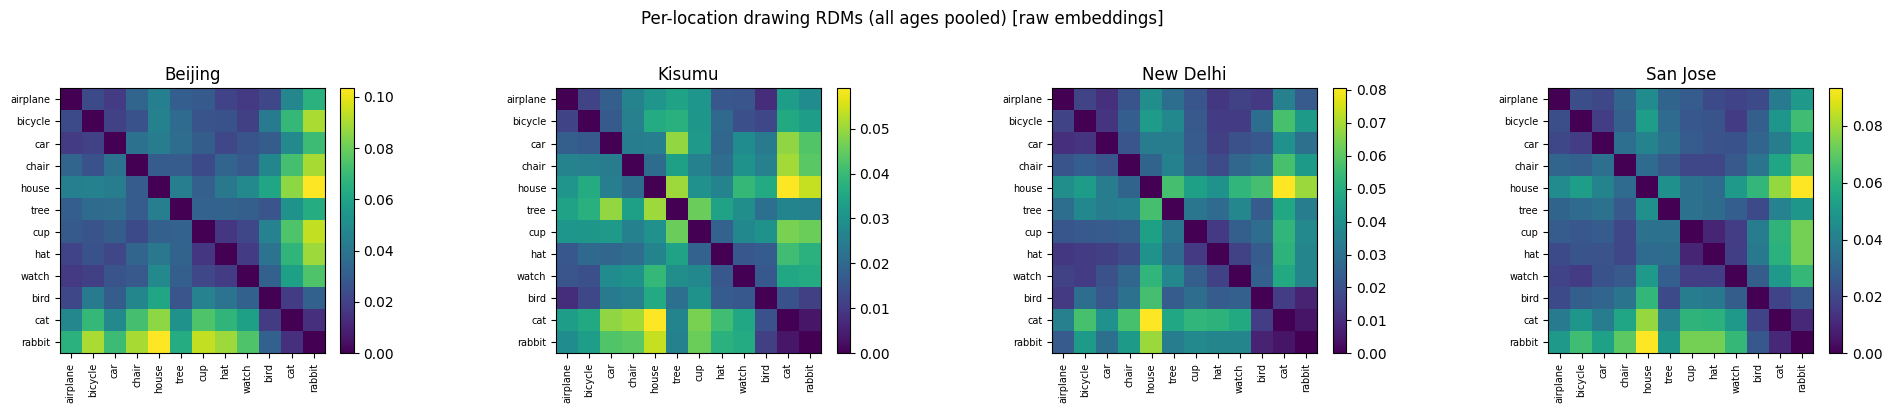

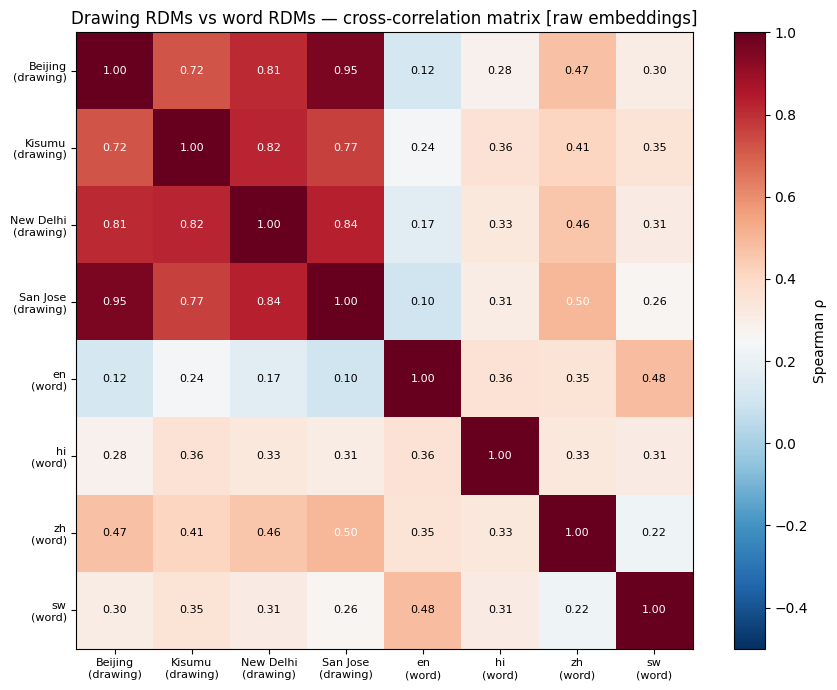

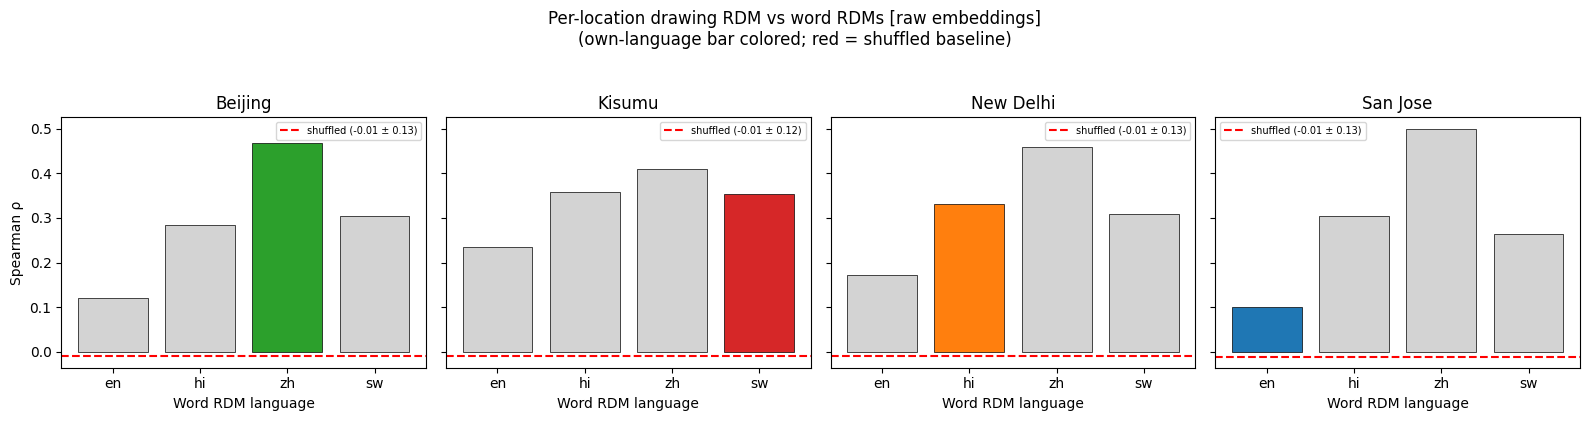

Computed 24 drawing RDMs ([z-scored embeddings])


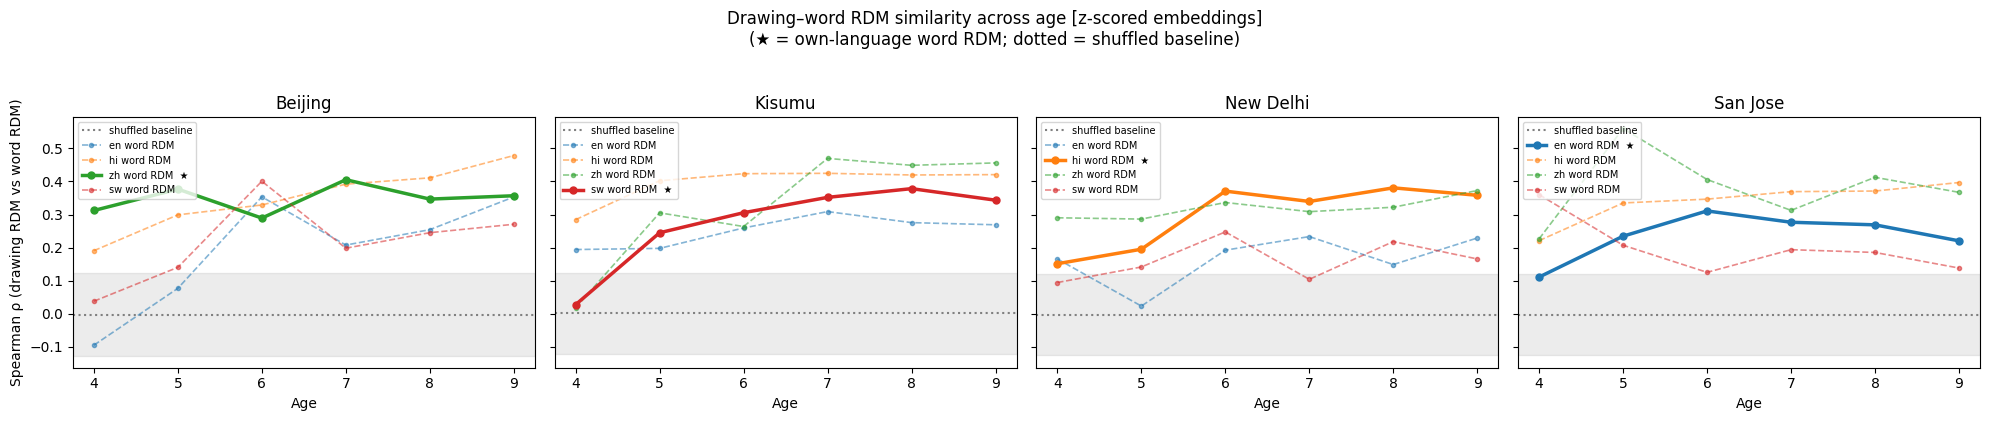

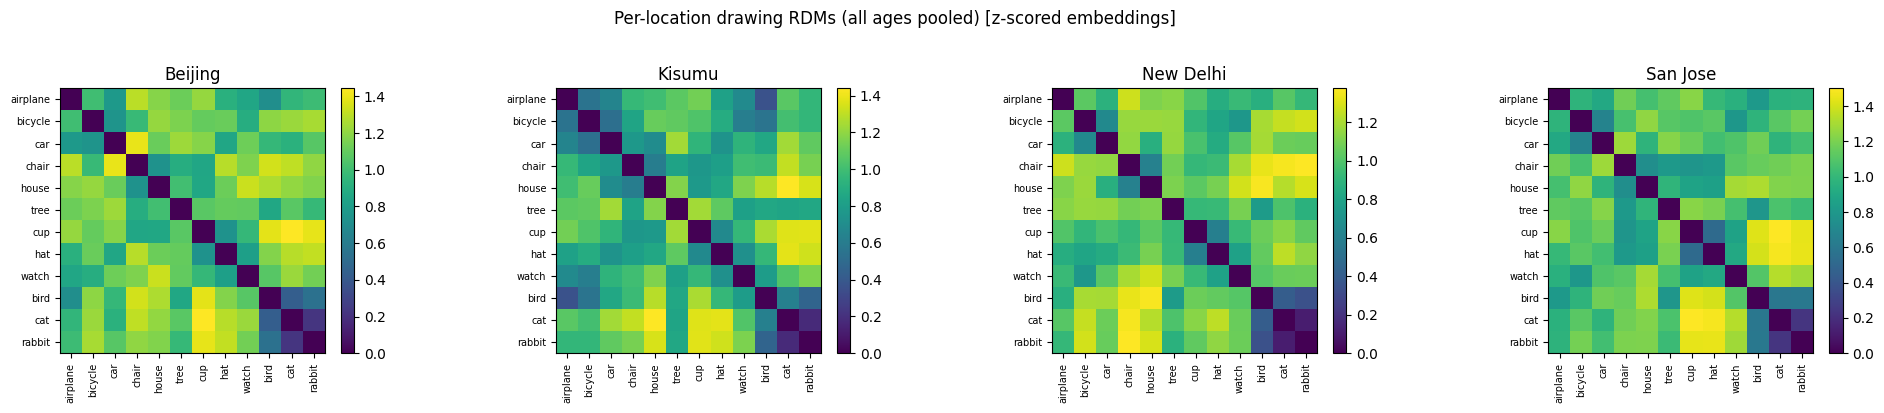

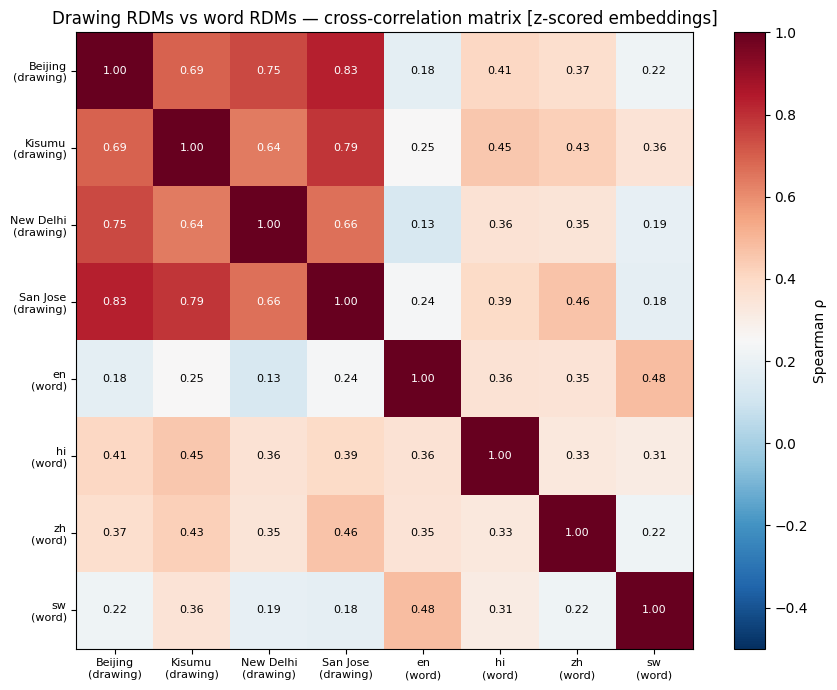

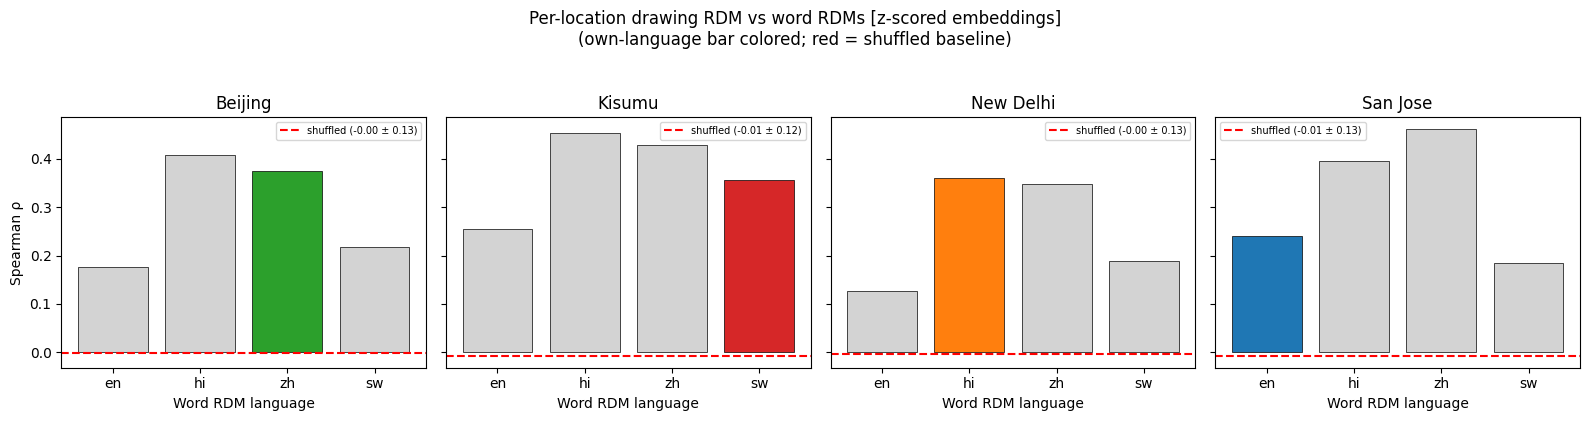

In [ ]:
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# ── Helpers ───────────────────────────────────────────────────────────────────
def lower_tri_vec(m):
    idx = np.tril_indices(m.shape[0], k=-1)
    return m[idx]

def rdm_corr(a, b):
    return spearmanr(lower_tri_vec(a), lower_tri_vec(b))[0]

def shuffled_baseline(rdm, n=500, seed=42):
    rng = np.random.default_rng(seed)
    v = lower_tri_vec(rdm)
    rhos = [spearmanr(v, rng.permutation(v))[0] for _ in range(n)]
    return np.mean(rhos), np.std(rhos)

CAT_REMAP     = {'bike': 'bicycle'}
CAT_REMAP_INV = {'bicycle': 'bike'}

location_lang = {
    'Beijing':   'zh',
    'Kisumu':    'sw',
    'New Delhi': 'hi',
    'San Jose':  'en',
}

lang_colors = {'en': 'C0', 'hi': 'C1', 'zh': 'C2', 'sw': 'C3'}

# ── Word RDMs (shared; reordering is z-score-independent) ────────────────────
trans_cats    = translations['en'].tolist()
cats_for_lookup = [CAT_REMAP.get(CAT_REMAP_INV.get(c, c), c) for c in CATEGORIES_GROUPED]
word_rdm_idx  = [trans_cats.index(c) for c in cats_for_lookup]

word_rdms_ordered = {
    lang: rdm[np.ix_(word_rdm_idx, word_rdm_idx)]
    for lang, rdm in {'en': rdm_en, 'hi': rdm_hi, 'zh': rdm_zh, 'sw': rdm_sw}.items()
}

locations = sorted(stores['location'].unique())
ages      = sorted(stores['age'].unique())

# ── Core builder: drawing RDMs from (optionally z-scored) embeddings ──────────
def build_drawing_rdms(stores_df, zscore=False):
    """
    Returns:
        drawing_rdms : dict[(loc, age)] -> RDM
        loc_rdms     : dict[loc]        -> RDM  (all ages pooled)
    """
    emb_col = 'embedding_zscored' if zscore else 'embedding'

    def get_mean_vec(rows):
        return np.mean(np.vstack(rows[emb_col].values), axis=0)

    def rdm_from_vecs(vecs):
        return 1 - cosine_similarity(np.vstack(vecs))

    drawing_rdms = {}
    for loc in locations:
        loc_df = stores_df[stores_df['location'] == loc]
        for age in ages:
            age_df = loc_df[loc_df['age'] == age]
            vecs, ok = [], True
            for cat in CATEGORIES_GROUPED:
                stores_cat = CAT_REMAP_INV.get(cat, cat)
                rows = age_df[age_df['drawing_category'] == stores_cat]
                if rows.empty:
                    ok = False; break
                vecs.append(get_mean_vec(rows))
            if ok:
                drawing_rdms[(loc, age)] = rdm_from_vecs(vecs)

    loc_rdms = {}
    for loc in locations:
        loc_df = stores_df[stores_df['location'] == loc]
        vecs, ok = [], True
        for cat in CATEGORIES_GROUPED:
            stores_cat = CAT_REMAP_INV.get(cat, cat)
            rows = loc_df[loc_df['drawing_category'] == stores_cat]
            if rows.empty:
                ok = False; break
            vecs.append(get_mean_vec(rows))
        if ok:
            loc_rdms[loc] = rdm_from_vecs(vecs)

    return drawing_rdms, loc_rdms

# ── All four plots, parametrised on pre-built RDMs ───────────────────────────
def plot_all(drawing_rdms, loc_rdms, title_suffix=''):

    # 1. Drawing–word RDM correlation across age, per location
    fig, axes = plt.subplots(1, len(locations), figsize=(5 * len(locations), 4), sharey=True)
    for ax, loc in zip(axes, locations):
        own_lang     = location_lang[loc]
        own_word_rdm = word_rdms_ordered[own_lang]
        base_mean, base_std = shuffled_baseline(own_word_rdm)
        ax.axhline(base_mean, color='gray', ls=':', lw=1.5, label='shuffled baseline')
        ax.axhspan(base_mean - base_std, base_mean + base_std, color='gray', alpha=0.15)

        for lang, word_rdm in word_rdms_ordered.items():
            age_vals, rho_vals = [], []
            for age in ages:
                if (loc, age) not in drawing_rdms:
                    continue
                age_vals.append(age)
                rho_vals.append(rdm_corr(drawing_rdms[(loc, age)], word_rdm))
            is_own = lang == own_lang
            ax.plot(age_vals, rho_vals,
                    color=lang_colors[lang],
                    lw=2.5 if is_own else 1.2,
                    ls='-' if is_own else '--',
                    alpha=1.0 if is_own else 0.55,
                    marker='o', markersize=5 if is_own else 3,
                    label=f'{lang} word RDM{"  ★" if is_own else ""}')
        ax.set_title(loc)
        ax.set_xlabel('Age')
        ax.set_xticks(ages)
        ax.legend(fontsize=7, loc='upper left')

    axes[0].set_ylabel('Spearman ρ (drawing RDM vs word RDM)')
    plt.suptitle(
        f'Drawing–word RDM similarity across age{title_suffix}\n'
        '(★ = own-language word RDM; dotted = shuffled baseline)', y=1.04)
    plt.tight_layout()
    plt.show()

    # 2. Per-location average RDM heatmaps
    fig, axes = plt.subplots(1, len(loc_rdms), figsize=(5 * len(loc_rdms), 4))
    for ax, (loc, rdm) in zip(axes, loc_rdms.items()):
        im = ax.imshow(rdm, vmin=0, vmax=0.1 if not title_suffix else None, cmap='viridis')
        ax.set_title(loc)
        ax.set_xticks(range(len(CATEGORIES_GROUPED)))
        ax.set_yticks(range(len(CATEGORIES_GROUPED)))
        ax.set_xticklabels(CATEGORIES_GROUPED, rotation=90, fontsize=7)
        ax.set_yticklabels(CATEGORIES_GROUPED, fontsize=7)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle(f'Per-location drawing RDMs (all ages pooled){title_suffix}', y=1.02)
    plt.tight_layout()
    plt.show()

    # 3. Full cross-correlation matrix
    draw_labels = [f'{loc}\n(drawing)' for loc in loc_rdms]
    word_labels  = [f'{lang}\n(word)'   for lang in word_rdms_ordered]
    all_labels   = draw_labels + word_labels
    all_rdms     = list(loc_rdms.values()) + list(word_rdms_ordered.values())
    n = len(all_rdms)
    corr_mat = np.array([[rdm_corr(all_rdms[i], all_rdms[j])
                          for j in range(n)] for i in range(n)])

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr_mat, vmin=-0.5, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(n)); ax.set_xticklabels(all_labels, fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(all_labels, fontsize=8)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{corr_mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if abs(corr_mat[i,j]) > 0.5 else 'black')
    plt.colorbar(im, ax=ax, label='Spearman ρ')
    plt.title(f'Drawing RDMs vs word RDMs — cross-correlation matrix{title_suffix}')
    plt.tight_layout()
    plt.show()

    # 4. Bar chart per location
    fig, axes = plt.subplots(1, len(loc_rdms), figsize=(4 * len(loc_rdms), 4), sharey=True)
    for ax, (loc, draw_rdm) in zip(axes, loc_rdms.items()):
        own_lang   = location_lang[loc]
        langs      = list(word_rdms_ordered.keys())
        rhos       = [rdm_corr(draw_rdm, word_rdms_ordered[l]) for l in langs]
        base_mean, base_std = shuffled_baseline(draw_rdm)
        bar_colors = [lang_colors[l] if l == own_lang else 'lightgray' for l in langs]
        ax.bar(langs, rhos, color=bar_colors, zorder=2, edgecolor='k', linewidth=0.5)
        ax.axhline(base_mean, color='red', ls='--', lw=1.5,
                   label=f'shuffled ({base_mean:.2f} ± {base_std:.2f})')
        ax.set_title(loc)
        ax.set_xlabel('Word RDM language')
        ax.legend(fontsize=7)
    axes[0].set_ylabel('Spearman ρ')
    plt.suptitle(
        f'Per-location drawing RDM vs word RDMs{title_suffix}\n'
        '(own-language bar colored; red = shuffled baseline)', y=1.04)
    plt.tight_layout()
    plt.show()

# ── Run both versions ─────────────────────────────────────────────────────────
for zscore in (False, True):
    suffix = ' [z-scored embeddings]' if zscore else ' [raw embeddings]'
    drawing_rdms, loc_rdms = build_drawing_rdms(stores, zscore=zscore)
    print(f"Computed {len(drawing_rdms)} drawing RDMs ({suffix.strip()})")
    plot_all(drawing_rdms, loc_rdms, title_suffix=suffix)


In [74]:
drawing_rdms_corr = {
    (loc1, loc2): rdm_corr(rdm1, rdm2)
    for i, (loc1, rdm1) in enumerate(loc_rdms.items())
    for loc2, rdm2 in list(loc_rdms.items())[i+1:]
}
drawing_rdms_corr

{('Beijing', 'Kisumu'): np.float64(0.6917649514664441),
 ('Beijing', 'New Delhi'): np.float64(0.7472497651602131),
 ('Beijing', 'San Jose'): np.float64(0.8325853251226387),
 ('Kisumu', 'New Delhi'): np.float64(0.6370316250913266),
 ('Kisumu', 'San Jose'): np.float64(0.7872873395261456),
 ('New Delhi', 'San Jose'): np.float64(0.662999686880284)}

looks like overall the chinese embeddings predict the pattern of drawings across languages. the english embeddings having such low predictivity is also strange, especially looking at age-related change differences when z-scoring and when not. clearly z-scoring makes a big difference. just going to print the english and san jose rdms here for posterity.

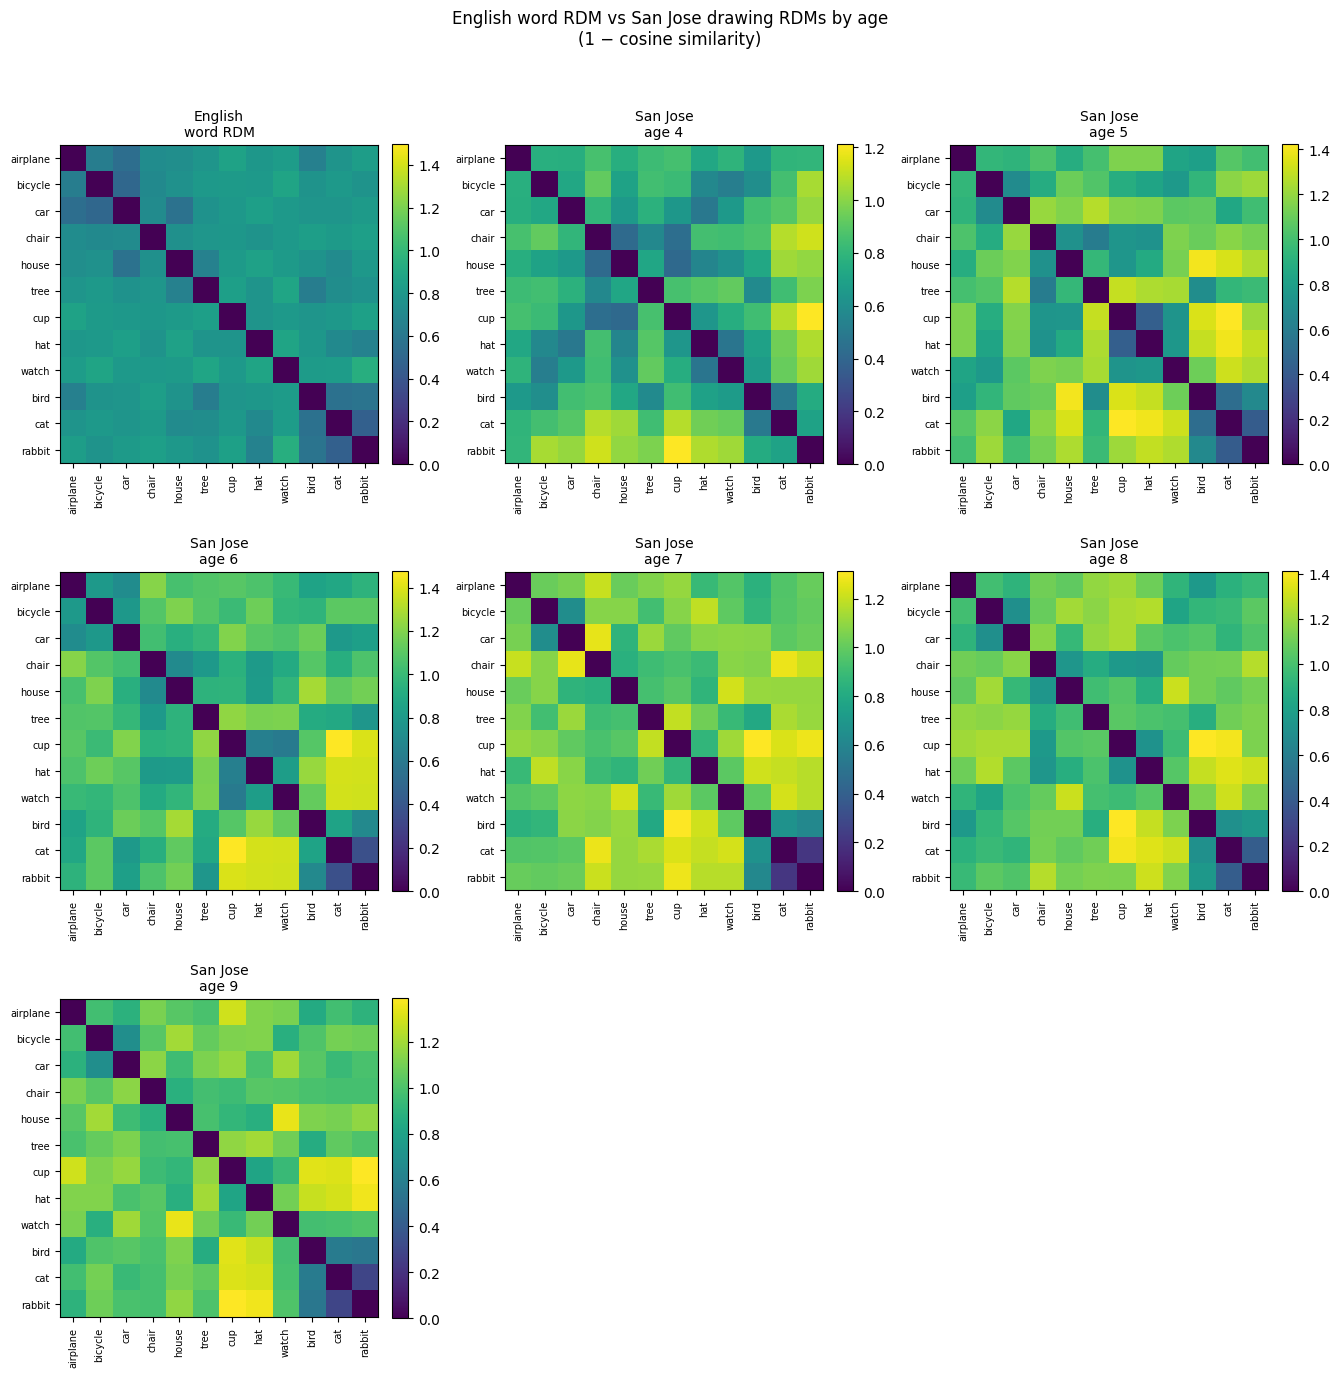

In [67]:
sj_ages = sorted([age for (loc, age) in drawing_rdms if loc == 'San Jose'])
n_panels = 1 + len(sj_ages)   # English word RDM + one per age

n_cols = 3
n_rows = (n_panels + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.5 * n_rows))
axes = axes.flatten()

# English word RDM
ax = axes[0]
im = ax.imshow(word_rdms_ordered['en'], vmin=0, vmax=1.5, cmap='viridis')
ax.set_title('English\nword RDM', fontsize=10)
ax.set_xticks(range(len(CATEGORIES_GROUPED)))
ax.set_yticks(range(len(CATEGORIES_GROUPED)))
ax.set_xticklabels(CATEGORIES_GROUPED, rotation=90, fontsize=7)
ax.set_yticklabels(CATEGORIES_GROUPED, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# San Jose drawing RDMs per age
for i, age in enumerate(sj_ages):
    ax = axes[i + 1]
    rdm = drawing_rdms[('San Jose', age)]
    im = ax.imshow(rdm, vmin=0, vmax=rdm.max(), cmap='viridis')
    ax.set_title(f'San Jose\nage {age}', fontsize=10)
    ax.set_xticks(range(len(CATEGORIES_GROUPED)))
    ax.set_yticks(range(len(CATEGORIES_GROUPED)))
    ax.set_xticklabels(CATEGORIES_GROUPED, rotation=90, fontsize=7)
    ax.set_yticklabels(CATEGORIES_GROUPED, fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# hide any unused axes
for ax in axes[n_panels:]:
    ax.set_visible(False)

plt.suptitle('English word RDM vs San Jose drawing RDMs by age\n(1 − cosine similarity)', y=1.02)
plt.tight_layout()
plt.show()

ah yeah lots of thematic overlap being captured by the english model.

trying ridge regression now to predict vision embeddings from language embeddings. noting that this is imperfect since CLIP embeddings have english. also some questions in general around whether we want to z-score embeddings, whether we want to evaluate on cosine similarity or on 

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics.pairwise import cosine_similarity as cos_sim_matrix

# ── Semantic groups ────────────────────────────────────────────────────────────
GROUP_SLICES = [slice(0, 3), slice(3, 6), slice(6, 9), slice(9, 12)]
cat_to_group = {}
for gi, sl in enumerate(GROUP_SLICES):
    for cat in CATEGORIES_GROUPED[sl]:
        cat_to_group[cat] = gi

# ── Word embedding matrix per language ────────────────────────────────────────
model_map = {'en': en, 'hi': hi, 'zh': zh, 'sw': sw}
word_vecs = {}
for lang in ['en', 'hi', 'zh', 'sw']:
    model = model_map[lang]
    vecs = []
    for cat in CATEGORIES_GROUPED:
        lookup = CAT_REMAP.get(CAT_REMAP_INV.get(cat, cat), cat)
        row = translations[translations['en'] == lookup].iloc[0]
        vec = model.get_word_vector(str(row[lang]))
        vecs.append(vec / (np.linalg.norm(vec) + 1e-10))
    word_vecs[lang] = np.vstack(vecs)

# ── Build individual-drawing arrays ───────────────────────────────────────────
def build_XY(df, lang, zscore=False):
    emb_col = 'embedding_zscored' if zscore else 'embedding'
    X_rows, Y_rows, groups = [], [], []
    for ci, cat in enumerate(CATEGORIES_GROUPED):
        rows = df[df['drawing_category'] == CAT_REMAP_INV.get(cat, cat)]
        if rows.empty:
            continue
        wv = word_vecs[lang][ci]
        for emb in rows[emb_col].values:
            e = np.array(emb, dtype=float)
            # NOTE: normalizing Y here means we're evaluating on cosine similarity, not raw dot product, try without normalizing too?
            Y_rows.append(e / (np.linalg.norm(e) + 1e-10))
            X_rows.append(wv)
            groups.append(ci)
    if not X_rows:
        return None, None, None
    return np.vstack(X_rows), np.vstack(Y_rows), np.array(groups)

# ── Vector cosine similarity (1-D inputs) ─────────────────────────────────────
def _cos(a, b):
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10))

# ── Evaluation functions ───────────────────────────────────────────────────────
def eval_pairwise_acc(pred, Y_test, Y_train):
    pred = np.asarray(pred).ravel()
    sims_test  = np.array([_cos(pred, y) for y in Y_test])
    sims_other = np.array([_cos(pred, y) for y in Y_train])
    return float(np.mean([(sims_test[k] > sims_other).mean()
                          for k in range(len(sims_test))]))

def eval_cosine_sim(pred, Y_test, Y_train):
    pred = np.asarray(pred).ravel().reshape(1, -1)
    return float(cos_sim_matrix(pred, Y_test).mean())

EVAL_FNS = {
    'pairwise_acc': eval_pairwise_acc,
    'cosine_sim':   eval_cosine_sim,
}

# ── Raw visual clustering baseline ────────────────────────────────────────────
def raw_drawing_baseline(Y, groups):
    n_cats = len(CATEGORIES_GROUPED)
    scores = []
    for i in range(n_cats):
        mask_i = groups == i
        if mask_i.sum() < 2:
            scores.append(np.nan); continue
        Y_i, Y_other = Y[mask_i], Y[~mask_i]
        cat_scores = []
        for k in range(len(Y_i)):
            query = Y_i[k]
            sims_same  = np.array([_cos(query, Y_i[j]) for j in range(len(Y_i)) if j != k])
            sims_other = np.array([_cos(query, y) for y in Y_other])
            if len(sims_same):
                cat_scores.append(float(np.mean(
                    [(sims_same[m] > sims_other).mean() for m in range(len(sims_same))])))
        scores.append(np.mean(cat_scores) if cat_scores else np.nan)
    return np.array(scores)

# ── Ridge LOOCV (individual drawings) ─────────────────────────────────────────
ALPHAS = np.logspace(-2, 4, 20)

def ridge_loocv(X_own, Y, groups, X_other_langs,
                metric='pairwise_acc', normalize_Y=False):
    eval_fn = EVAL_FNS[metric]
    if normalize_Y:
        Y = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + 1e-10)

    n_cats = len(CATEGORIES_GROUPED)
    same, other_lang, related, unrelated = [], [], [], []

    def fit(X_tr, Y_tr):
        return RidgeCV(alphas=ALPHAS, fit_intercept=False).fit(X_tr, Y_tr)

    for i in range(n_cats):
        test_mask = groups == i
        if test_mask.sum() == 0:
            for lst in (same, other_lang, related, unrelated):
                lst.append(np.nan)
            continue

        Y_test = Y[test_mask]
        gi     = cat_to_group[CATEGORIES_GROUPED[i]]

        # same: leave out cat i only
        train_mask_i = ~test_mask
        clf_i = fit(X_own[train_mask_i], Y[train_mask_i])
        wv_i  = X_own[test_mask][0:1]
        same.append(eval_fn(clf_i.predict(wv_i)[0], Y_test, Y[train_mask_i]))

        # other languages: same leave-one-out, refit per lang
        ol_scores = []
        for X_ol in X_other_langs:
            if X_ol is None: continue
            clf_ol = fit(X_ol[train_mask_i], Y[train_mask_i])
            ol_scores.append(eval_fn(
                clf_ol.predict(X_ol[test_mask][0:1])[0], Y_test, Y[train_mask_i]))
        other_lang.append(float(np.mean(ol_scores)) if ol_scores else np.nan)

        # related: leave-two-out (i AND j), predict i with word_vec_j
        rel_idx = [j for j, c in enumerate(CATEGORIES_GROUPED)
                   if cat_to_group[c] == gi and j != i]
        rel_scores = []
        for j in rel_idx:
            mask_j   = groups == j
            train_ij = ~(test_mask | mask_j)
            if train_ij.sum() == 0: continue
            clf_ij = fit(X_own[train_ij], Y[train_ij])
            wv_j   = X_own[mask_j][0:1]
            rel_scores.append(eval_fn(clf_ij.predict(wv_j)[0], Y_test, Y[train_ij]))
        related.append(float(np.mean(rel_scores)) if rel_scores else np.nan)

        # unrelated: leave-two-out (i AND k), predict i with word_vec_k
        unrel_idx = [j for j, c in enumerate(CATEGORIES_GROUPED)
                     if cat_to_group[c] != gi]
        unrel_scores = []
        for k in unrel_idx:
            mask_k   = groups == k
            train_ik = ~(test_mask | mask_k)
            if train_ik.sum() == 0: continue
            clf_ik = fit(X_own[train_ik], Y[train_ik])
            wv_k   = X_own[mask_k][0:1]
            unrel_scores.append(eval_fn(clf_ik.predict(wv_k)[0], Y_test, Y[train_ik]))
        unrelated.append(float(np.mean(unrel_scores)) if unrel_scores else np.nan)

    return (np.array(same), np.array(other_lang),
            np.array(related), np.array(unrelated))


In [126]:
# making sure the tuple shapes make sense before running the full analyses
x,y,group = build_XY(stores[stores['location'] == 'San Jose'], 'en', 'pairwise_acc')
x.shape, y.shape, group[20:70]

((716, 300),
 (716, 512),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1]))

In [127]:
# ── Run all analyses for both metrics ─────────────────────────────────────────
langs = ['en', 'hi', 'zh', 'sw']

def run_loocv_for_df(df, metric, zscore=False):
    """Return {lang: {cond: array}} for a single dataframe slice."""
    out = {}
    for lang in langs:
        X, Y, groups = build_XY(df, lang, zscore)
        if X is None: continue
        other_X = [build_XY(df, l)[0] for l in langs if l != lang]
        s, ol, rel, unrel = ridge_loocv(X, Y, groups, other_X, metric=metric)
        out[lang] = {'same': s, 'other_lang': ol, 'related': rel, 'unrelated': unrel}
    return out

def visual_baselines_for_df(df):
    """Return (pairwise_arr, cosine_arr, cosine_cross_null) for a df slice."""
    X0, Y0, g0 = build_XY(df, 'en')
    if Y0 is None:
        return None, None, None
    pa = raw_drawing_baseline(Y0, g0)
    cos_scores = []
    cross_sims = []
    for i in range(len(CATEGORIES_GROUPED)):
        mask = g0 == i
        Y_i = Y0[mask]
        if mask.sum() >= 2:
            sims = [_cos(Y_i[a], Y_i[b])
                    for a in range(len(Y_i)) for b in range(a+1, len(Y_i))]
            cos_scores.append(float(np.mean(sims)))
        else:
            cos_scores.append(np.nan)
        for j in np.where(g0 != i)[0]:
            cross_sims.append(_cos(Y0[np.where(mask)[0][0]], Y0[j]))
    return pa, np.array(cos_scores), float(np.mean(cross_sims))

# pooled (all ages)
results_pooled     = {loc: {} for loc in locations}
results_pooled_cos = {loc: {} for loc in locations}
baseline_pooled    = {}   # loc -> pairwise_acc array
baseline_pooled_cos= {}   # loc -> cosine_sim array
cosine_null        = {}   # loc -> float (cross-cat cosine null)

# per age
results_age     = {loc: {} for loc in locations}
results_age_cos = {loc: {} for loc in locations}
baseline_age    = {loc: {} for loc in locations}

zscore_pairwise = True
# z-scoring cosine similarity values since the range is so small that it makes it hard to find noticeable differences between conditions (especially for the pooled analyses where the values are very low)
zscore_cosine = True
for loc in locations:
    loc_df = stores[stores['location'] == loc]
    results_pooled[loc]     = run_loocv_for_df(loc_df, 'pairwise_acc', zscore_pairwise)
    results_pooled_cos[loc] = run_loocv_for_df(loc_df, 'cosine_sim', zscore_cosine)
    pa, ca, cn = visual_baselines_for_df(loc_df)
    baseline_pooled[loc], baseline_pooled_cos[loc], cosine_null[loc] = pa, ca, cn

    for age in ages:
        age_df = loc_df[loc_df['age'] == age]
        results_age[loc][age]     = run_loocv_for_df(age_df, 'pairwise_acc', zscore_pairwise)
        results_age_cos[loc][age] = run_loocv_for_df(age_df, 'cosine_sim', zscore_cosine)
        pa, ca, _ = visual_baselines_for_df(age_df)
        baseline_age[loc][age] = pa

print("Done.")


Done.


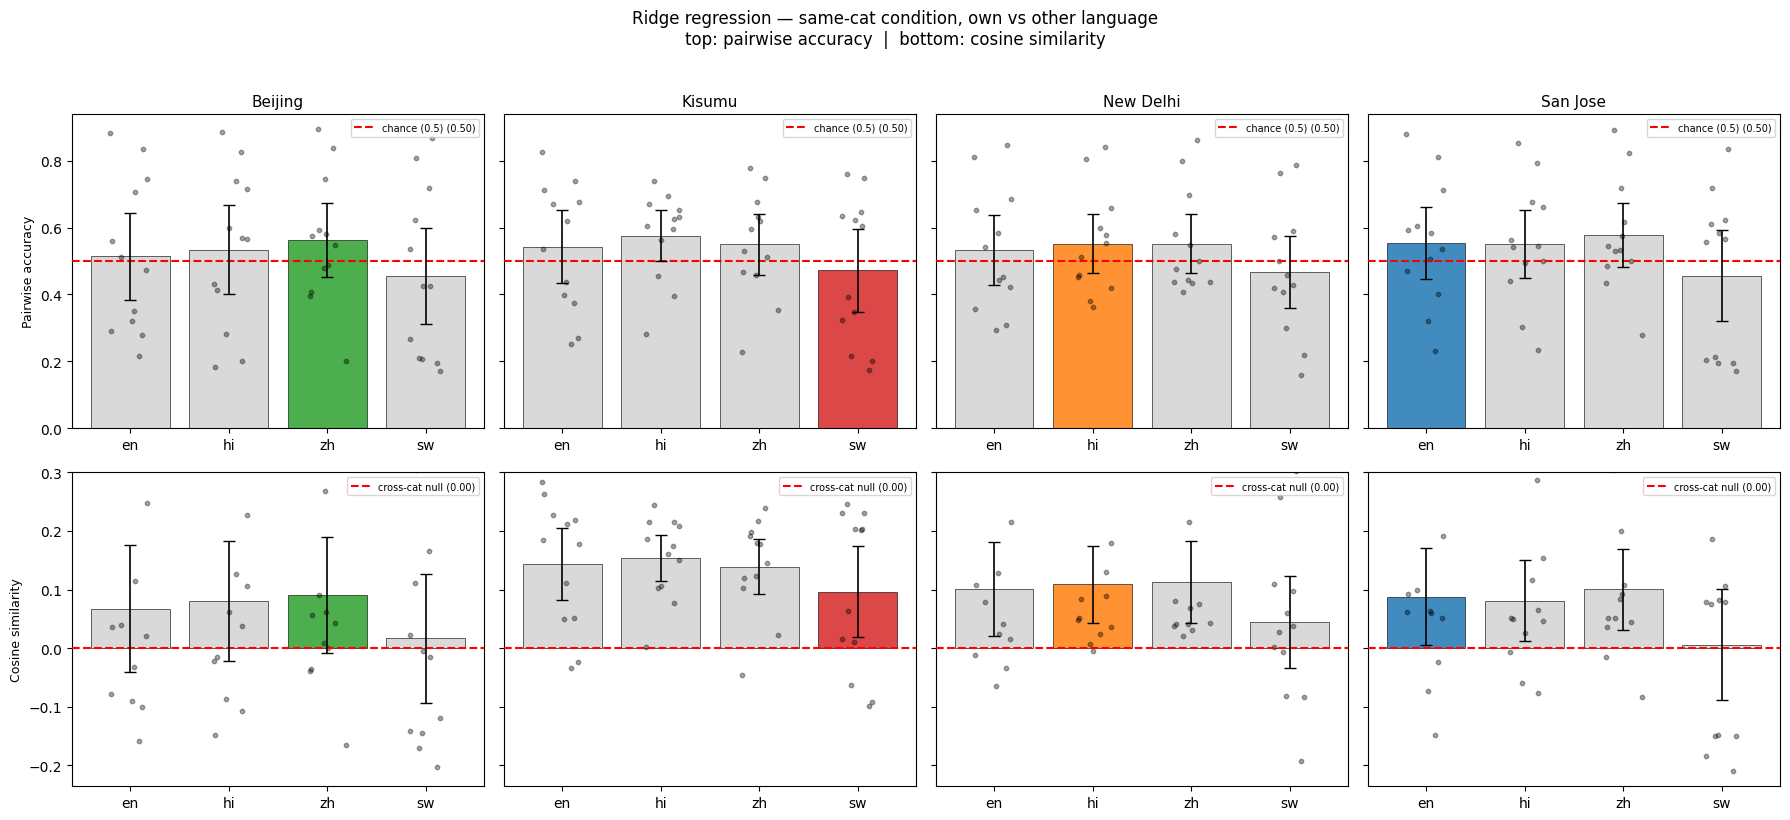

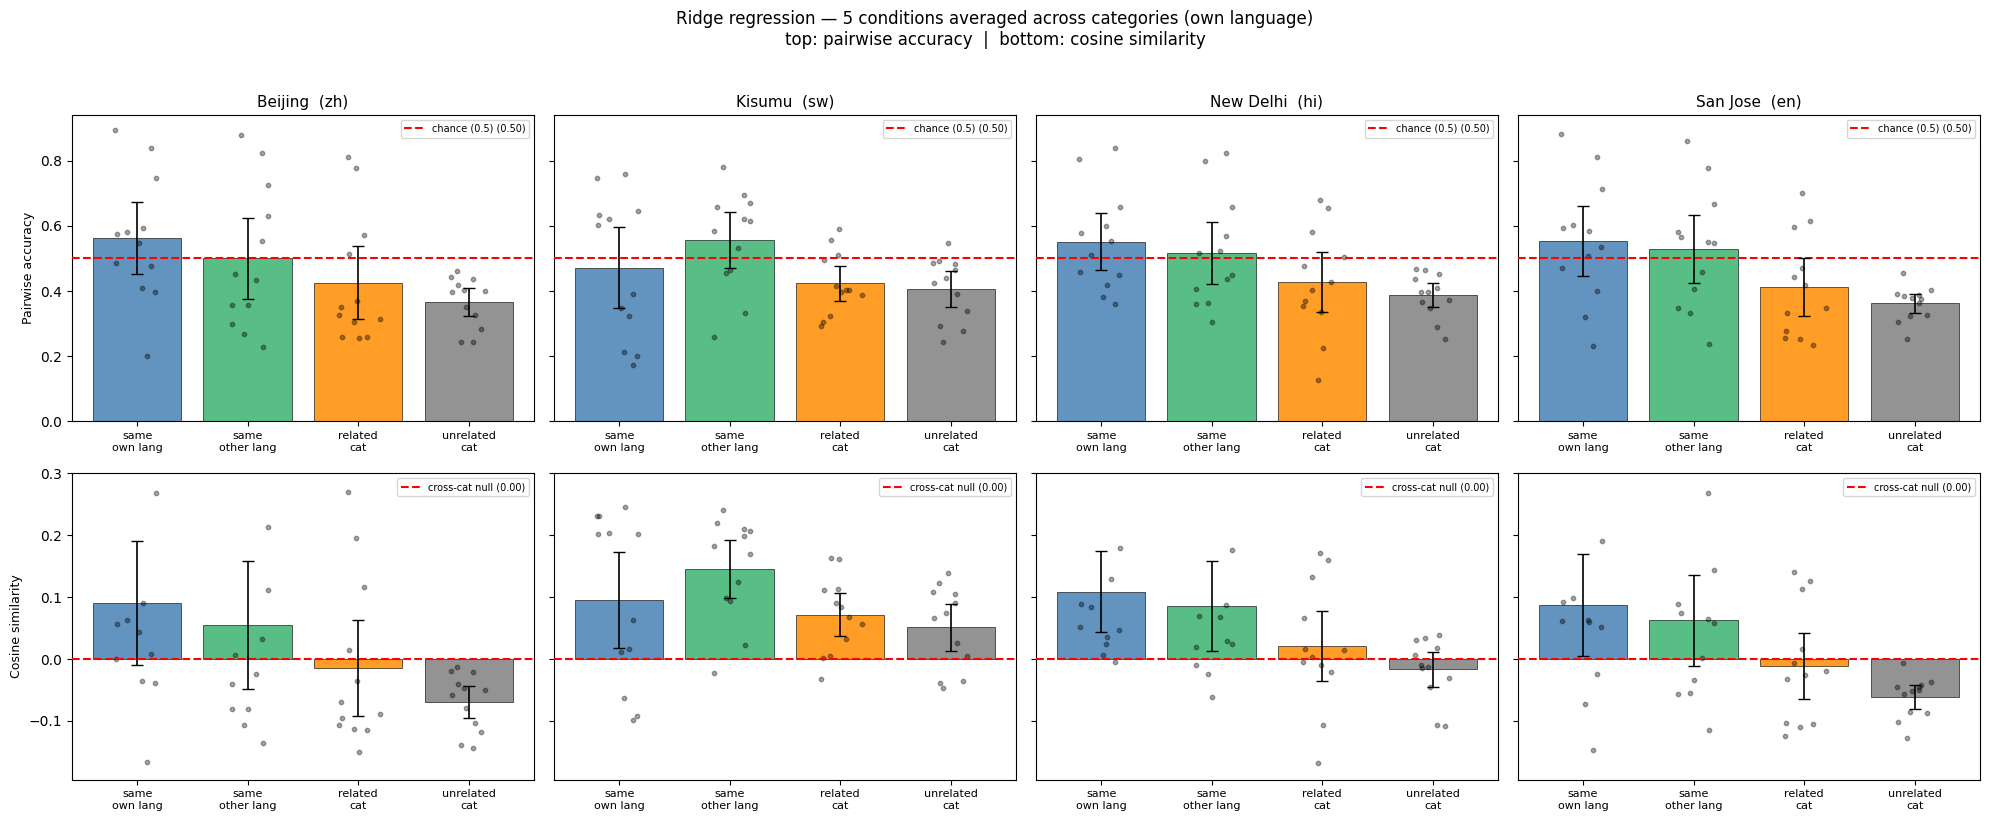

In [128]:
cond_order = ['same', 'other_lang', 'related', 'unrelated']
cond_colors_bar = {
    'same': 'steelblue', 'other_lang': 'mediumseagreen',
    'related': 'darkorange', 'unrelated': 'gray', 'visual': 'firebrick',
}
cond_labels_bar = {
    'same': 'same\nown lang', 'other_lang': 'same\nother lang',
    'related': 'related\ncat', 'unrelated': 'unrelated\ncat', 'visual': 'visual\nbaseline',
}

METRIC_ROWS = [
    # (label, res_pooled, vis_pooled, null_val, null_label)
    ('Pairwise accuracy', results_pooled,     baseline_pooled,     0.5,        'chance (0.5)'),
    ('Cosine similarity', results_pooled_cos, baseline_pooled_cos, 0, 'cross-cat null'),
]

def bar_with_dots(ax, x_pos, vals, cat_arrs, colors, rng_seed=0):
    ax.bar(x_pos, vals, color=colors, edgecolor='k', linewidth=0.5, alpha=0.85, zorder=2)
    
    errs = []
    for cat_v in cat_arrs:
        if cat_v is None:
            errs.append(0)
            continue
        valid = np.asarray(cat_v)[~np.isnan(cat_v)]
        if len(valid) < 2:
            errs.append(0)
            continue
        errs.append(1.96 * np.std(valid, ddof=1) / np.sqrt(len(valid)))  # 95% CI

    ax.errorbar(
        x_pos, vals, yerr=errs,
        fmt='none', ecolor='black', elinewidth=1.2, capsize=4,
        zorder=5
    )

    for xi, cat_v in zip(x_pos, cat_arrs):
        if cat_v is None: continue
        valid = np.asarray(cat_v)[~np.isnan(cat_v)]
        if len(valid) == 0: continue
        jitter = np.random.default_rng(rng_seed + int(xi * 10)).uniform(-0.2, 0.2, len(valid))
        ax.scatter(xi + jitter, valid, color='k', alpha=0.35, s=10, zorder=3)

def add_null(ax, null_val, null_label, loc):
    null = null_val[loc] if isinstance(null_val, dict) else null_val
    ax.axhline(null, color='red', ls='--', lw=1.5,
               label=f'{null_label} ({null:.2f})', zorder=4)
    return null

# ── Plot 1: same-cat, 4 languages per location ────────────────────────────────
fig, axes = plt.subplots(2, len(locations), figsize=(4.5 * len(locations), 8), sharey='row')
for row, (ylabel, res_dict, vis_dict, null_val, null_label) in enumerate(METRIC_ROWS):
    for col, loc in enumerate(locations):
        ax = axes[row][col]
        own_lang = location_lang[loc]
        vals  = [np.nanmean(res_dict[loc][l]['same']) if l in res_dict[loc] else np.nan
                 for l in langs]
        cats  = [res_dict[loc][l]['same'] if l in res_dict[loc] else None for l in langs]
        colors= [lang_colors[l] if l == own_lang else 'lightgray' for l in langs]
        bar_with_dots(ax, range(len(langs)), vals, cats, colors)
        add_null(ax, null_val, null_label, loc)
        ax.set_xticks(range(len(langs))); ax.set_xticklabels(langs)
        if row == 0: ax.set_title(loc, fontsize=11)
        if col == 0: ax.set_ylabel(ylabel, fontsize=9)
        if row == 0:
            ax.set_ylim(bottom=0)
        else:
            ax.set_ylim(top=0.3)
        ax.legend(fontsize=7)

plt.suptitle('Ridge regression — same-cat condition, own vs other language\n'
             'top: pairwise accuracy  |  bottom: cosine similarity', y=1.02)
plt.tight_layout(); plt.show()

# ── Plot 2: 5 conditions, own-language model per location ─────────────────────
fig, axes = plt.subplots(2, len(locations), figsize=(5 * len(locations), 8), sharey='row')
for row, (ylabel, res_dict, vis_dict, null_val, null_label) in enumerate(METRIC_ROWS):
    for col, loc in enumerate(locations):
        ax = axes[row][col]
        own_lang = location_lang[loc]
        r = res_dict[loc].get(own_lang)
        if r is None: continue
        vb = vis_dict.get(loc) if vis_dict else None
        vals  = [np.nanmean(r[c]) if c != 'visual' else (np.nanmean(vb) if vb is not None else np.nan)
                 for c in cond_order]
        cats  = [r[c] if c != 'visual' else vb for c in cond_order]
        colors= [cond_colors_bar[c] for c in cond_order]
        x = np.arange(len(cond_order))
        bar_with_dots(ax, x, vals, cats, colors)
        add_null(ax, null_val, null_label, loc)
        ax.set_xticks(x); ax.set_xticklabels([cond_labels_bar[c] for c in cond_order], fontsize=8)
        if row == 0: ax.set_title(f'{loc}  ({own_lang})', fontsize=11)
        if col == 0: ax.set_ylabel(ylabel, fontsize=9)
        if row == 0:
            ax.set_ylim(bottom=0)
        else:
            ax.set_ylim(top=0.3)
        ax.legend(fontsize=7)

plt.suptitle('Ridge regression — 5 conditions averaged across categories (own language)\n'
             'top: pairwise accuracy  |  bottom: cosine similarity', y=1.02)
plt.tight_layout(); plt.show()


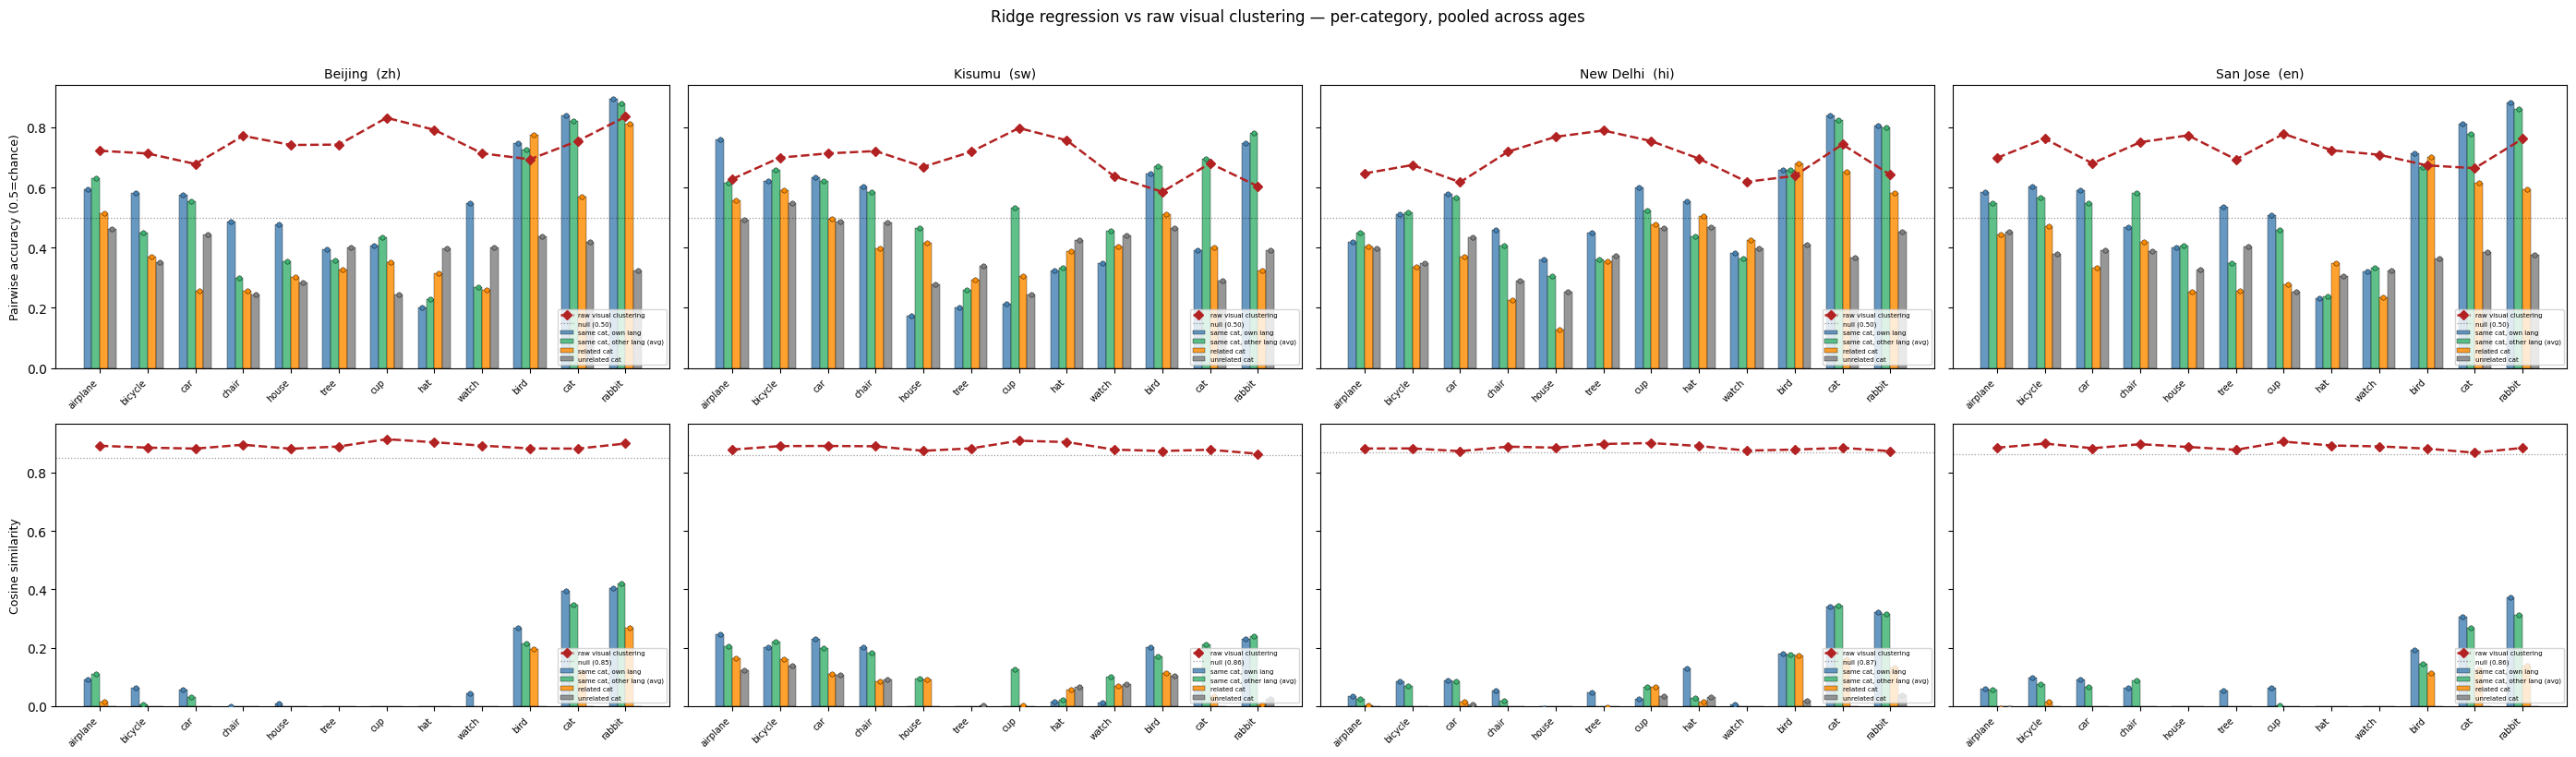

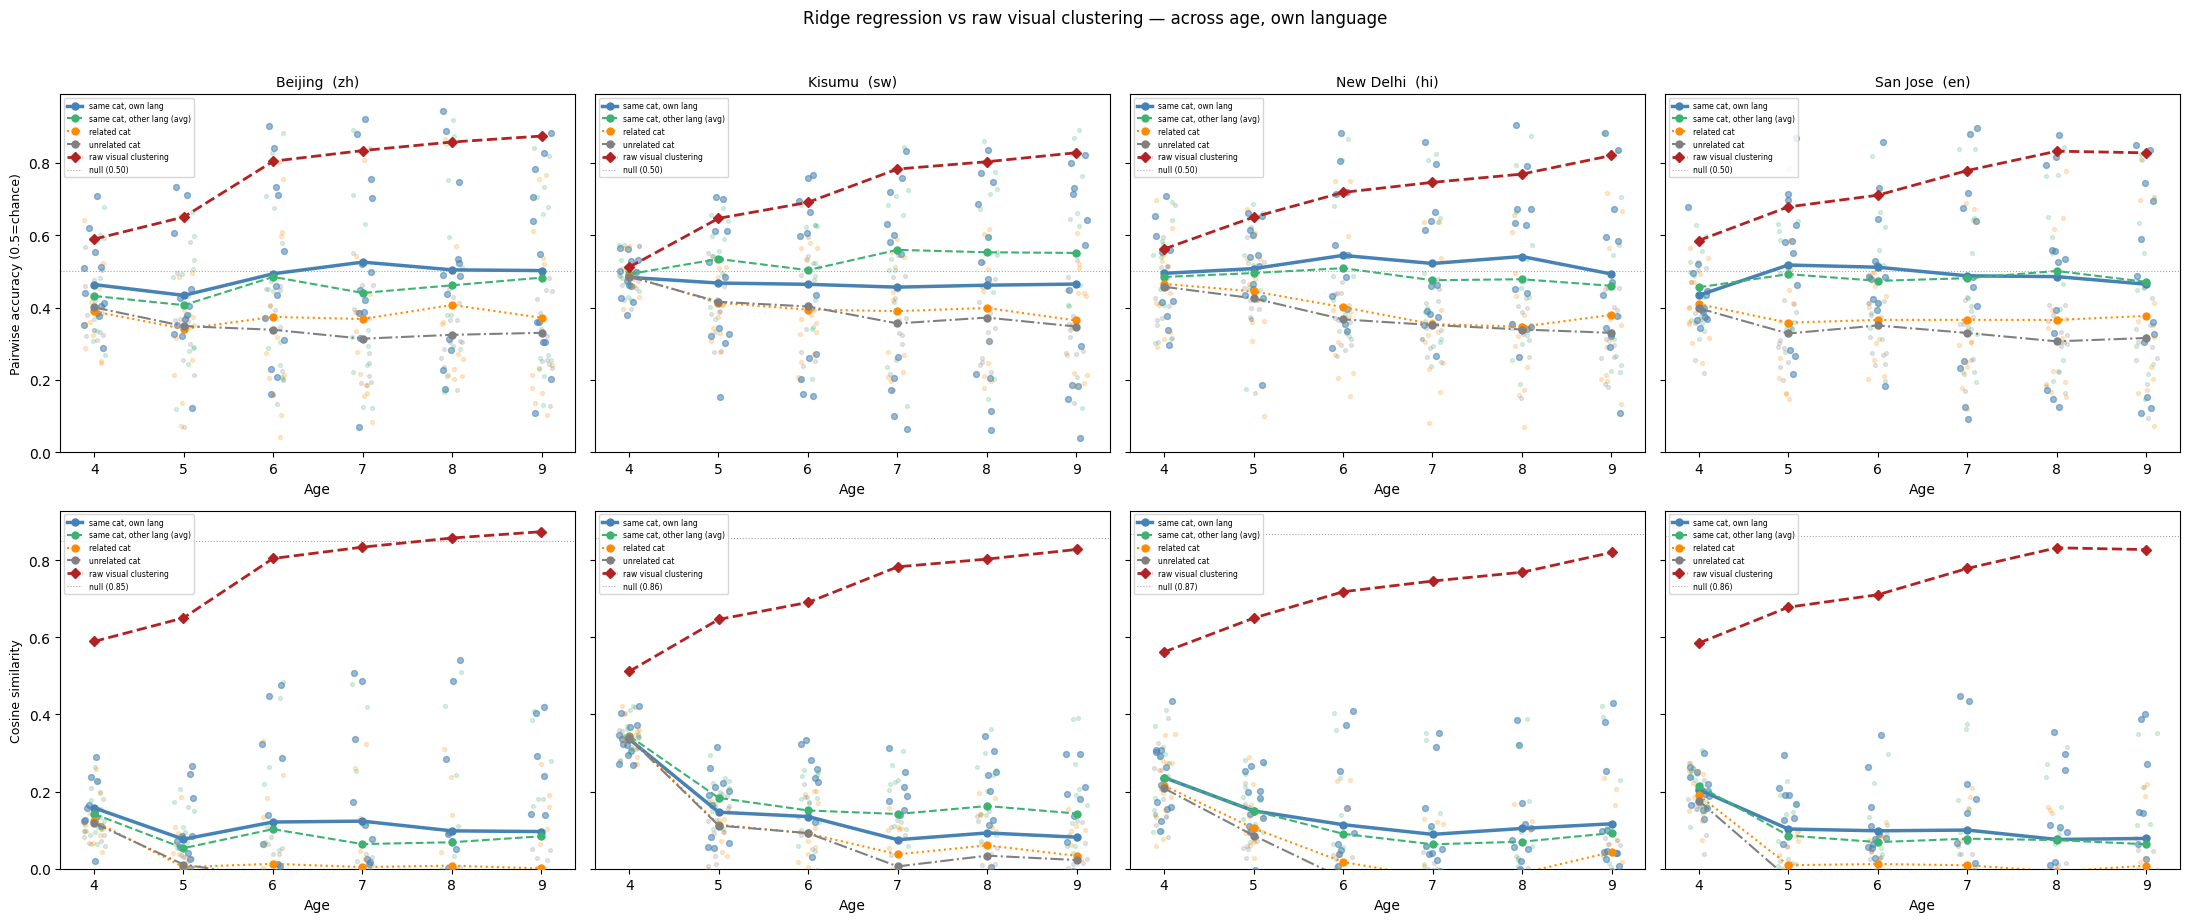

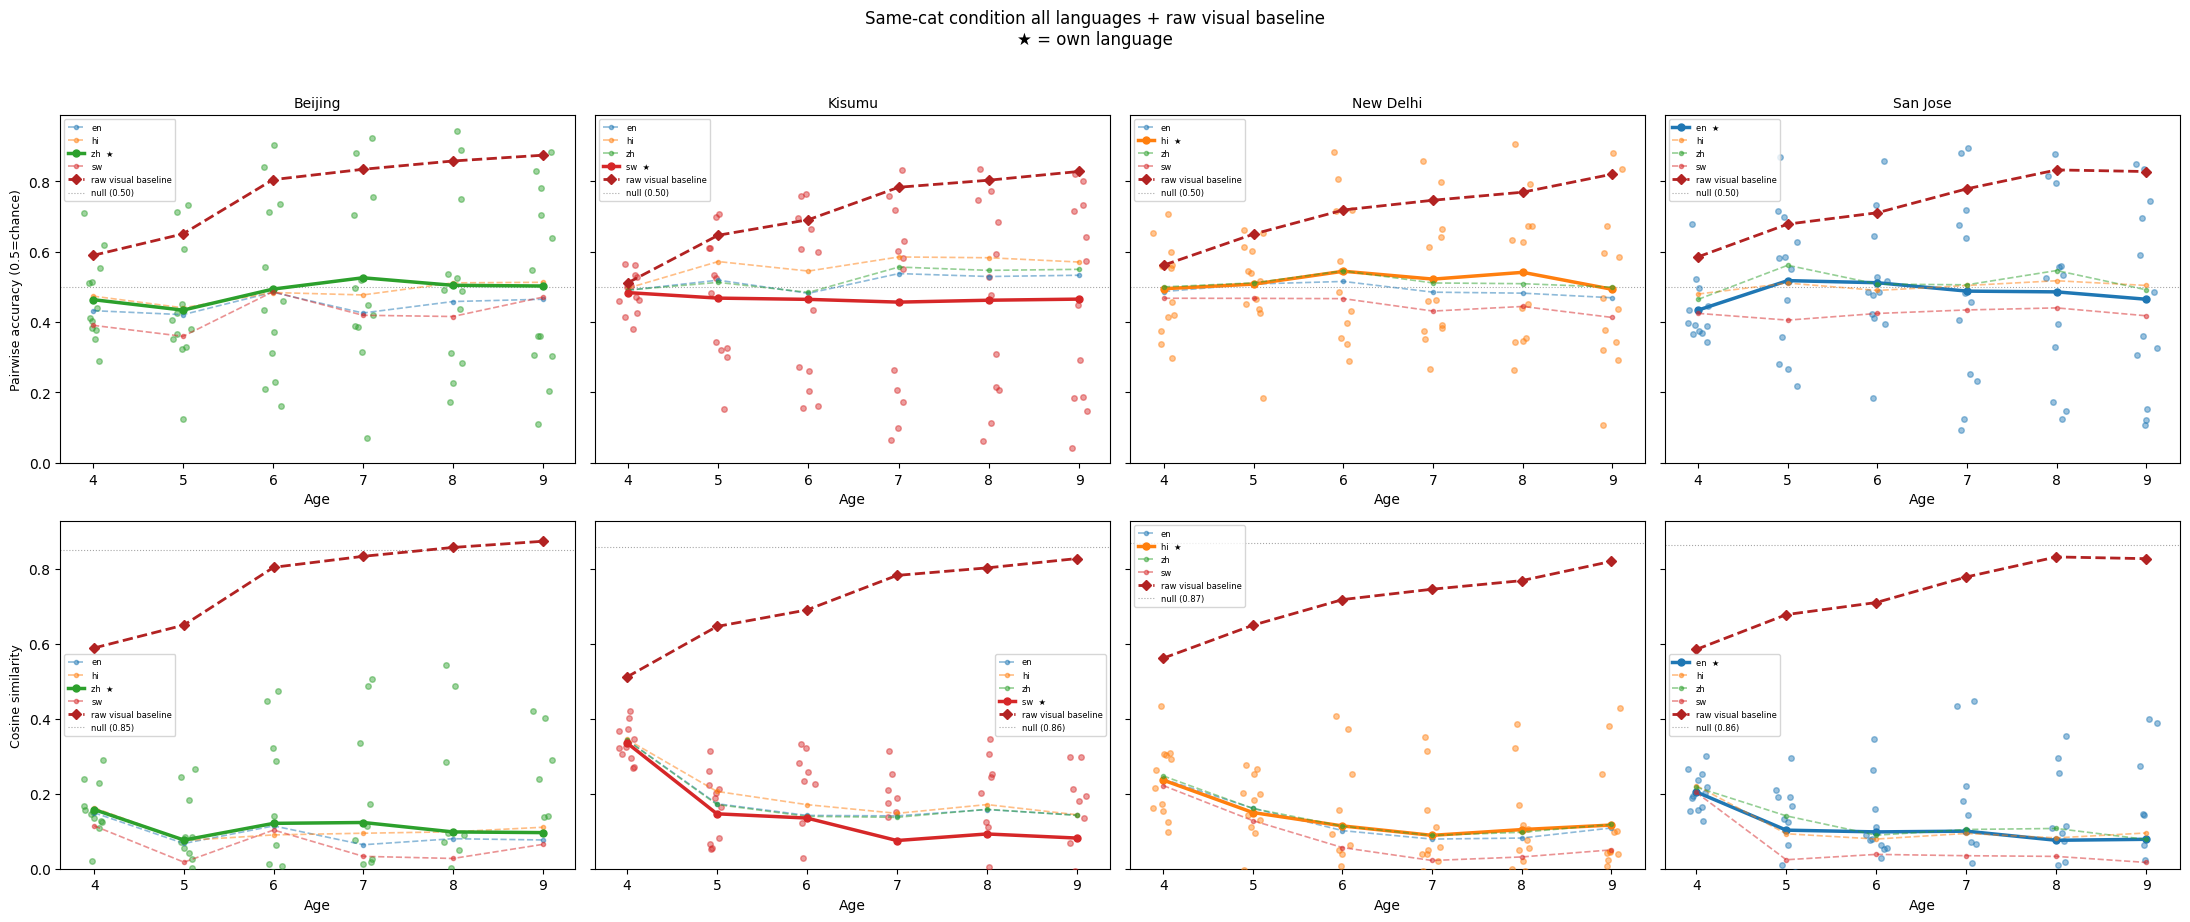

In [130]:
rng = np.random.default_rng(0)

cond_colors = {
    'same': 'steelblue', 'other_lang': 'mediumseagreen',
    'related': 'darkorange', 'unrelated': 'gray', 'visual': 'firebrick',
}
cond_labels = {
    'same': 'same cat, own lang', 'other_lang': 'same cat, other lang (avg)',
    'related': 'related cat', 'unrelated': 'unrelated cat',
    'visual': 'raw visual clustering',
}
cond_order = ['same', 'other_lang', 'related', 'unrelated']

def get_age_result(res, loc, lang, age):
    return res[loc].get(age, {}).get(lang)

def get_bv_line(bv_dict, loc, ages):
    """Return (ages_list, means_list) for a visual baseline dict."""
    bv_ages = [a for a in ages if bv_dict[loc].get(a) is not None]
    bv_means = [bv_dict[loc][a][~np.isnan(bv_dict[loc][a])].mean() for a in bv_ages]
    return bv_ages, bv_means

METRICS = [
    ('Pairwise accuracy (0.5=chance)', results_pooled,     results_age,     baseline_pooled,     baseline_pooled,     0.5),
    ('Cosine similarity',              results_pooled_cos, results_age_cos, baseline_pooled_cos, baseline_pooled_cos, cosine_null),
]

# ── PLOT A: Pooled — per-category bars + visual baseline ──────────────────────
fig, axes = plt.subplots(2, len(locations), figsize=(7 * len(locations), 8), sharey='row')
for row, (ylabel, res_pool, _, vis_pool, _, null_val) in enumerate(METRICS):
    for col, loc in enumerate(locations):
        ax = axes[row][col]
        own_lang = location_lang[loc]
        r = res_pool[loc].get(own_lang)
        if r is None: continue
        x, width = np.arange(len(CATEGORIES_GROUPED)), 0.17
        offsets = np.linspace(-1.5, 1.5, 4) * width
        for k, cond in enumerate(cond_order):
            vals = r[cond]
            ax.bar(x + offsets[k], np.nan_to_num(vals), width,
                   color=cond_colors[cond], alpha=0.82, edgecolor='k', linewidth=0.3,
                   label=cond_labels[cond])
            for ci, v in enumerate(vals):
                if not np.isnan(v):
                    ax.scatter(ci + offsets[k], v, color=cond_colors[cond],
                               s=15, zorder=5, edgecolors='k', linewidths=0.3)
        bv = vis_pool.get(loc)
        if bv is not None:
            ax.plot(x, np.nan_to_num(bv), color=cond_colors['visual'],
                    lw=1.8, ls='--', marker='D', markersize=5, label=cond_labels['visual'], zorder=6)
        null = null_val[loc] if isinstance(null_val, dict) else null_val
        ax.axhline(null, color='k', lw=0.9, ls=':', alpha=0.4, label=f'null ({null:.2f})')
        if row == 0: ax.set_title(f'{loc}  ({own_lang})', fontsize=10)
        ax.set_xticks(x); ax.set_xticklabels(CATEGORIES_GROUPED, rotation=45, ha='right', fontsize=7)
        ax.set_ylim(bottom=0); ax.legend(fontsize=5, loc='lower right')
        if col == 0: ax.set_ylabel(ylabel, fontsize=9)
plt.suptitle('Ridge regression vs raw visual clustering — per-category, pooled across ages', y=1.02)
plt.tight_layout(); plt.show()

# ── PLOT B: Across age — 4 conditions + visual baseline, own language ─────────
fig, axes = plt.subplots(2, len(locations), figsize=(5.5 * len(locations), 9), sharey='row')
for row, (ylabel, _, res_ag, _, vis_ag_dict, null_val) in enumerate(METRICS):
    for col, loc in enumerate(locations):
        ax = axes[row][col]
        own_lang = location_lang[loc]
        for cond in cond_order:
            age_vals, means = [], []
            for age in ages:
                r = get_age_result(res_ag, loc, own_lang, age)
                if r is None: continue
                valid = r[cond][~np.isnan(r[cond])]
                if len(valid) == 0: continue
                ax.scatter(age + rng.uniform(-0.12, 0.12, len(valid)), valid,
                           color=cond_colors[cond],
                           alpha=0.55 if cond == 'same' else 0.2,
                           s=18 if cond == 'same' else 8, zorder=3)
                age_vals.append(age); means.append(valid.mean())
            ls = {'same': '-', 'other_lang': '--', 'related': ':', 'unrelated': '-.'}[cond]
            ax.plot(age_vals, means, color=cond_colors[cond],
                    lw=2.5 if cond == 'same' else 1.5, ls=ls,
                    marker='o', markersize=5, label=cond_labels[cond], zorder=4)
        bv_ages, bv_means = get_bv_line(baseline_age, loc, ages)  # pairwise visual baseline
        ax.plot(bv_ages, bv_means, color=cond_colors['visual'],
                lw=2, ls='--', marker='D', markersize=5, label=cond_labels['visual'], zorder=5)
        null = null_val[loc] if isinstance(null_val, dict) else null_val
        ax.axhline(null, color='k', lw=0.8, ls=':', alpha=0.35, label=f'null ({null:.2f})')
        if row == 0: ax.set_title(f'{loc}  ({own_lang})', fontsize=10)
        ax.set_xlabel('Age'); ax.set_xticks(ages); ax.set_ylim(bottom=0)
        ax.legend(fontsize=5.5, loc='upper left')
        if col == 0: ax.set_ylabel(ylabel, fontsize=9)
plt.suptitle('Ridge regression vs raw visual clustering — across age, own language', y=1.02)
plt.tight_layout(); plt.show()

# ── PLOT C: Same-cat, all languages + visual baseline, across age ──────────────
fig, axes = plt.subplots(2, len(locations), figsize=(5.5 * len(locations), 9), sharey='row')
for row, (ylabel, _, res_ag, _, _, null_val) in enumerate(METRICS):
    for col, loc in enumerate(locations):
        ax = axes[row][col]
        own_lang = location_lang[loc]
        for lang in langs:
            is_own = lang == own_lang
            age_vals, means = [], []
            for age in ages:
                r = get_age_result(res_ag, loc, lang, age)
                if r is None: continue
                valid = r['same'][~np.isnan(r['same'])]
                if len(valid) == 0: continue
                if is_own:
                    ax.scatter(age + rng.uniform(-0.12, 0.12, len(valid)), valid,
                               color=lang_colors[lang], alpha=0.45, s=16, zorder=3)
                age_vals.append(age); means.append(valid.mean())
            ax.plot(age_vals, means, color=lang_colors[lang],
                    lw=2.5 if is_own else 1.2, ls='-' if is_own else '--',
                    alpha=1.0 if is_own else 0.5, marker='o',
                    markersize=5 if is_own else 3,
                    label=f'{lang}{"  ★" if is_own else ""}', zorder=4)
        bv_ages, bv_means = get_bv_line(baseline_age, loc, ages)
        ax.plot(bv_ages, bv_means, color=cond_colors['visual'],
                lw=2, ls='--', marker='D', markersize=5, label='raw visual baseline', zorder=5)
        null = null_val[loc] if isinstance(null_val, dict) else null_val
        ax.axhline(null, color='k', lw=0.8, ls=':', alpha=0.35, label=f'null ({null:.2f})')
        if row == 0: ax.set_title(loc, fontsize=10)
        ax.set_xlabel('Age'); ax.set_xticks(ages); ax.set_ylim(bottom=0)
        ax.legend(fontsize=6)
        if col == 0: ax.set_ylabel(ylabel, fontsize=9)
plt.suptitle('Same-cat condition all languages + raw visual baseline\n★ = own language', y=1.02)
plt.tight_layout(); plt.show()

1. add dino embeddings, see if you can predict dino from clip as well; clip from dino; clip from clip
2. filter down to recognizable drawings; bucket based on recognizability and then map
3. to zscore or not zscore?
4. add pca and cka to directly compare spaces; maybe alternative word embeddings like https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/tree/main, but then you have to account for the fact that words are by default aligned across languages
5. compare to adult drawings